In [1]:
# Authenticate with Google Cloud
from google.colab import auth
auth.authenticate_user()
print('Authentication successful!')

Authentication successful!


In [2]:
# Install and import required libraries
!pip install google-cloud-bigquery pyarrow fastparquet -q

from google.cloud import bigquery
import pandas as pd
import numpy as np
import os
import time

print('Libraries imported!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 38.0 MB/s eta 0:00:00
Libraries imported!


In [3]:
# IMPORTANT: Replace with YOUR Google Cloud Project ID
PROJECT_ID = 'recommendation-system-488500'  # ← CHANGE THIS!

# Initialize BigQuery client
client = bigquery.Client(project=PROJECT_ID)
print(f'BigQuery client initialized with project: {PROJECT_ID}')

BigQuery client initialized with project: recommendation-system-488500


In [4]:
# Check schemas (these queries are tiny, almost zero cost)
query = """
SELECT column_name, data_type
FROM `bigquery-public-data.stackoverflow.INFORMATION_SCHEMA.COLUMNS`
WHERE table_name IN ('posts_questions', 'posts_answers')
ORDER BY table_name, ordinal_position
"""
schema_df = client.query(query).to_dataframe()
print('posts_questions columns:')
q_cols = schema_df[schema_df['column_name'].isin(
    ['id','title','body','tags','score','view_count','answer_count','accepted_answer_id','creation_date']
)]
for _, r in q_cols.iterrows():
    print(f"  {r['column_name']}: {r['data_type']}")

posts_questions columns:
  id: INT64
  title: STRING
  body: STRING
  accepted_answer_id: STRING
  answer_count: STRING
  creation_date: TIMESTAMP
  score: INT64
  tags: STRING
  view_count: STRING
  id: INT64
  title: STRING
  body: STRING
  accepted_answer_id: INT64
  answer_count: INT64
  creation_date: TIMESTAMP
  score: INT64
  tags: STRING
  view_count: INT64


In [5]:
# STEP 3.1: Define our top 30 tags and their allocations
# We hardcode the top 30 tags (from our earlier query) o avoid
# spending quota on re-fetching them.

TOP_TAGS_WITH_COUNTS = [
    ('javascript', 2426570), ('python', 2026601), ('java', 1866055),
    ('c#', 1559381), ('php', 1445727), ('android', 1386427),
    ('html', 1146211), ('jquery', 1029550), ('c++', 776812),
    ('css', 771839), ('ios', 674972), ('mysql', 651399),
    ('sql', 643126), ('r', 464228), ('node.js', 442785),
    ('reactjs', 415789), ('arrays', 398816), ('c', 385497),
    ('asp.net', 370120), ('json', 346393), ('ruby-on-rails', 334196),
    ('.net', 323461), ('python-3.x', 323063), ('sql-server', 322908),
    ('swift', 318725), ('django', 297351), ('objective-c', 292496),
    ('angular', 284418), ('excel', 269405), ('angularjs', 262553)
]

TOP_TAGS = [t for t, _ in TOP_TAGS_WITH_COUNTS]
top_tags_df = pd.DataFrame(TOP_TAGS_WITH_COUNTS, columns=['tag_name', 'question_count'])

# Calculate stratified allocation
TOTAL_QUESTIONS = 500_000
MIN_PER_TAG = 5_000
NUM_TAGS = len(TOP_TAGS)  # 30

reserved = MIN_PER_TAG * NUM_TAGS  # 150,000
proportional_pool = TOTAL_QUESTIONS - reserved  # 350,000
total_tag_questions = top_tags_df['question_count'].sum()

allocations = {}
for tag, count in TOP_TAGS_WITH_COUNTS:
    proportional_share = int(proportional_pool * (count / total_tag_questions))
    allocations[tag] = MIN_PER_TAG + proportional_share

# Adjust to hit exactly 500K
current_total = sum(allocations.values())
diff = TOTAL_QUESTIONS - current_total
allocations[TOP_TAGS[0]] += diff  # adjust most popular tag

# Display allocation plan
print('STRATIFIED SAMPLING PLAN')
print('=' * 65)
print(f'{"Tag":<20s} {"Allocated":>10s} {"% of 500K":>10s}')
print('-' * 65)
for tag in TOP_TAGS:
    pct = allocations[tag] / TOTAL_QUESTIONS * 100
    bar = '█' * int(pct * 2)
    print(f"  {tag:<20s} {allocations[tag]:>8,} {pct:>9.1f}%  {bar}")
print('-' * 65)
print(f"  {'TOTAL':<20s} {sum(allocations.values()):>8,} {100.0:>9.1f}%")
print(f'\n Every tag gets at least {MIN_PER_TAG:,} questions')

STRATIFIED SAMPLING PLAN
Tag                   Allocated  % of 500K
-----------------------------------------------------------------
  javascript             43,172       8.6%  █████████████████
  python                 36,869       7.4%  ██████████████
  java                   34,344       6.9%  █████████████
  c#                     29,522       5.9%  ███████████
  php                    27,734       5.5%  ███████████
  android                26,802       5.4%  ██████████
  html                   23,024       4.6%  █████████
  jquery                 21,190       4.2%  ████████
  c++                    17,215       3.4%  ██████
  css                    17,137       3.4%  ██████
  ios                    15,614       3.1%  ██████
  mysql                  15,243       3.0%  ██████
  sql                    15,113       3.0%  ██████
  r                      12,300       2.5%  ████
  node.js                11,963       2.4%  ████
  reactjs                11,538       2.3%  ████
  arrays   

In [6]:
# Save tags
top_tags_df.to_parquet('top_tags.parquet', index=False)
top_tags_df.to_csv('top_tags.csv', index=False)
print('Tags saved')

Tags saved


In [7]:
# STEP 3.2: Build the SINGLE optimized query
#
# How this works:
# 1. For each question, we extract all its tags (UNNEST + SPLIT)
# 2. We keep only tags that are in our top 30 list
# 3. We assign each question a "primary_tag" — the most popular
#    tag it has (to avoid counting a question under multiple tags)
# 4. We use ROW_NUMBER() to rank questions within each primary_tag
# 5. We use a CASE statement to set the limit per tag
#
# This scans the table ONCE (~35 GB) instead of 30 times (~1 TB)

# Build the tag priority CASE statement
# Tags are ordered by popularity — the first match becomes the primary tag
# This ensures each question is assigned to exactly ONE tag (the most popular one it has)
tag_priority_cases = []
for i, tag in enumerate(TOP_TAGS):
    # Escape special characters for SQL
    escaped = tag.replace("'", "\\'")
    tag_priority_cases.append(f"WHEN tags LIKE '%|{escaped}|%' OR tags LIKE '{escaped}|%' OR tags LIKE '%|{escaped}' OR tags = '{escaped}' THEN '{escaped}'")

tag_priority_sql = "\n        ".join(tag_priority_cases)

# Build the per-tag limit CASE statement
limit_cases = []
for tag in TOP_TAGS:
    escaped = tag.replace("'", "\\'")
    limit_cases.append(f"WHEN primary_tag = '{escaped}' THEN {allocations[tag]}")
limit_sql = "\n            ".join(limit_cases)

# The full optimized query
query_questions = f"""
WITH tagged_questions AS (
    -- Step 1: Assign each question a primary tag (most popular tag it has)
    SELECT
        id, title, body, tags, score, view_count,
        answer_count, accepted_answer_id, creation_date,
        CASE
            {tag_priority_sql}
        END AS primary_tag
    FROM `bigquery-public-data.stackoverflow.posts_questions`
    WHERE score >= 1
      AND answer_count >= 1
      AND title IS NOT NULL
      AND body IS NOT NULL
      AND tags IS NOT NULL
),
ranked_questions AS (
    -- Step 2: Rank questions within each primary tag by score
    SELECT
        *,
        ROW_NUMBER() OVER (
            PARTITION BY primary_tag
            ORDER BY score DESC
        ) as tag_rank
    FROM tagged_questions
    WHERE primary_tag IS NOT NULL
)
-- Step 3: Take top N per tag based on allocation
SELECT
    id, title, body, tags, score, view_count,
    answer_count, accepted_answer_id, creation_date, primary_tag
FROM ranked_questions
WHERE tag_rank <= CASE
            {limit_sql}
            ELSE 0
        END
ORDER BY primary_tag, score DESC
"""

print('Query built successfully')
print(f'   Estimated data scanned: ~35 GB (well within 1 TB free tier)')
print(f'   Expected result: ~500,000 questions')

Query built successfully
   Estimated data scanned: ~35 GB (well within 1 TB free tier)
   Expected result: ~500,000 questions


In [8]:
# ============================================================
# STEP 3.3: Execute the query (this is the main extraction)
# ============================================================

print('Extracting 500K questions with stratified sampling...')
print('   This single query replaces 30 separate queries')
print('   Expected time: 3-8 minutes\n')

start = time.time()
questions_df = client.query(query_questions).to_dataframe()
elapsed = time.time() - start

print(f' Done in {elapsed:.1f}s')
print(f' Total questions extracted: {len(questions_df):,}')
print(f' Score range: {questions_df["score"].min()} to {questions_df["score"].max()}')
print(f' Unique primary tags: {questions_df["primary_tag"].nunique()}')

Extracting 500K questions with stratified sampling...
   This single query replaces 30 separate queries
   Expected time: 3-8 minutes

 Done in 35.8s
 Total questions extracted: 500,000
 Score range: 2 to 26621
 Unique primary tags: 30


In [9]:
# STEP 3.4: Verify tag distribution

tag_dist = questions_df['primary_tag'].value_counts()

print(' Tag Distribution in Extracted Dataset')
print('=' * 70)
print(f'{"":<3s} {"Tag":<20s} {"Count":>8s} {"Target":>8s} {"Match":>6s}  Distribution')
print('-' * 70)

max_count = tag_dist.max()
all_meet_minimum = True
for tag in TOP_TAGS:
    actual = tag_dist.get(tag, 0)
    target = allocations[tag]
    meets = '✅' if actual >= MIN_PER_TAG else '⚠️'
    if actual < MIN_PER_TAG:
        all_meet_minimum = False
    bar = '█' * int(actual / max_count * 25)
    print(f"  {meets} {tag:<20s} {actual:>7,} {target:>7,}        {bar}")

print(f'\n Total: {len(questions_df):,}')
print(f' All tags ≥ {MIN_PER_TAG:,}: {all_meet_minimum}')

 Tag Distribution in Extracted Dataset
    Tag                     Count   Target  Match  Distribution
----------------------------------------------------------------------
  ✅ javascript            43,172  43,172        █████████████████████████
  ✅ python                36,869  36,869        █████████████████████
  ✅ java                  34,344  34,344        ███████████████████
  ✅ c#                    29,522  29,522        █████████████████
  ✅ php                   27,734  27,734        ████████████████
  ✅ android               26,802  26,802        ███████████████
  ✅ html                  23,024  23,024        █████████████
  ✅ jquery                21,190  21,190        ████████████
  ✅ c++                   17,215  17,215        █████████
  ✅ css                   17,137  17,137        █████████
  ✅ ios                   15,614  15,614        █████████
  ✅ mysql                 15,243  15,243        ████████
  ✅ sql                   15,113  15,113        ████████
  ✅ r   

In [10]:
# Sample questions from different tags
print(' Sample Questions:')
print('=' * 80)
for sample_tag in [TOP_TAGS[0], TOP_TAGS[1], TOP_TAGS[14], TOP_TAGS[-1]]:
    sample = questions_df[questions_df['primary_tag'] == sample_tag].head(2)
    print(f'\n  --- {sample_tag.upper()} ---')
    for _, row in sample.iterrows():
        print(f"  Score: {row['score']:>5} | Views: {row['view_count']:>8,} | {row['title'][:65]}")

 Sample Questions:

  --- JAVASCRIPT ---
  Score: 10953 | Views: 10,493,798 | How can I remove a specific item from an array?
  Score:  8447 | Views: 3,046,636 | How do I check if an element is hidden in jQuery?

  --- PYTHON ---
  Score: 12259 | Views: 3,023,452 | What does the "yield" keyword do?
  Score:  7713 | Views: 4,210,048 | What does if __name__ == "__main__": do?

  --- NODE.JS ---
  Score:  4706 | Views: 1,352,406 | What's the difference between tilde(~) and caret(^) in package.js
  Score:  2835 | Views:  977,353 | What is the --save option for npm install?

  --- ANGULARJS ---
  Score:  3390 | Views:  780,588 | AngularJS: Service vs provider vs factory
  Score:  1303 | Views:  646,650 | How do I access the $scope variable in browser's console using An


In [11]:
# Save questions
questions_df.to_parquet('questions_500k.parquet', index=False)
print(f' Questions saved to questions_500k.parquet')
print(f' File size: {os.path.getsize("questions_500k.parquet") / (1024**2):.1f} MB')

 Questions saved to questions_500k.parquet
 File size: 318.5 MB


In [12]:
# STEP 4.1: Extract top 3 answers per question (batched)

question_ids = questions_df['id'].tolist()
print(f' Total question IDs: {len(question_ids):,}')

BATCH_SIZE = 50000
all_answers = []

num_batches = (len(question_ids) + BATCH_SIZE - 1) // BATCH_SIZE
print(f' Processing in {num_batches} batches of {BATCH_SIZE:,}...')
print(f'   Each batch: ROW_NUMBER() ranks answers by score, keeps top 3\n')

total_start = time.time()

for batch_idx in range(num_batches):
    batch_start = batch_idx * BATCH_SIZE
    batch_end = min(batch_start + BATCH_SIZE, len(question_ids))
    batch_ids = question_ids[batch_start:batch_end]

    ids_str = ','.join(map(str, batch_ids))

    query_answers = f"""
    WITH ranked_answers AS (
        SELECT
            id,
            parent_id,
            body,
            score,
            creation_date,
            ROW_NUMBER() OVER (
                PARTITION BY parent_id
                ORDER BY score DESC
            ) as answer_rank
        FROM `bigquery-public-data.stackoverflow.posts_answers`
        WHERE parent_id IN ({ids_str})
          AND body IS NOT NULL
    )
    SELECT id, parent_id, body, score, creation_date, answer_rank
    FROM ranked_answers
    WHERE answer_rank <= 3
    ORDER BY parent_id, answer_rank
    """

    start = time.time()
    batch_answers = client.query(query_answers).to_dataframe()
    elapsed = time.time() - start

    all_answers.append(batch_answers)

    print(f'  Batch {batch_idx + 1}/{num_batches}: '
          f'{len(batch_answers):>8,} answers in {elapsed:.1f}s '
          f'(questions {batch_start+1:,} to {batch_end:,})')

# Combine all batches
answers_df = pd.concat(all_answers, ignore_index=True)
total_elapsed = time.time() - total_start

print(f'\n All answers extracted in {total_elapsed:.1f}s')
print(f' Total answers: {len(answers_df):,}')
print(f' Avg answers per question: {len(answers_df) / len(questions_df):.2f}')
print(f' Answer score range: {answers_df["score"].min()} to {answers_df["score"].max()}')

 Total question IDs: 500,000
 Processing in 10 batches of 50,000...
   Each batch: ROW_NUMBER() ranks answers by score, keeps top 3

  Batch 1/10:  126,556 answers in 18.7s (questions 1 to 50,000)
  Batch 2/10:  120,892 answers in 13.5s (questions 50,001 to 100,000)
  Batch 3/10:  127,626 answers in 12.2s (questions 100,001 to 150,000)
  Batch 4/10:  118,208 answers in 14.6s (questions 150,001 to 200,000)
  Batch 5/10:  135,927 answers in 16.1s (questions 200,001 to 250,000)
  Batch 6/10:  129,832 answers in 30.4s (questions 250,001 to 300,000)
  Batch 7/10:  111,550 answers in 13.0s (questions 300,001 to 350,000)
  Batch 8/10:  131,384 answers in 14.3s (questions 350,001 to 400,000)
  Batch 9/10:  111,889 answers in 12.1s (questions 400,001 to 450,000)
  Batch 10/10:  116,225 answers in 11.9s (questions 450,001 to 500,000)

 All answers extracted in 157.1s
 Total answers: 1,230,089
 Avg answers per question: 2.46
 Answer score range: -42 to 34269


In [13]:
# STEP 4.2: Mark accepted answers

accepted_ids = set(
    questions_df['accepted_answer_id']
    .dropna()
    .astype(int)
    .tolist()
)
answers_df['is_accepted'] = answers_df['id'].isin(accepted_ids)

print(f' Accepted answers found: {answers_df["is_accepted"].sum():,} '
      f'out of {len(answers_df):,} total '
      f'({answers_df["is_accepted"].mean()*100:.1f}%)')

 Accepted answers found: 388,441 out of 1,230,089 total (31.6%)


In [14]:
# Quick look at a sample question with its answers
print('Sample: Question with Top 3 Answers')
print('=' * 80)

sample_qid = questions_df.nlargest(1, 'score')['id'].values[0]
sample_q = questions_df[questions_df['id'] == sample_qid].iloc[0]
sample_answers = answers_df[answers_df['parent_id'] == sample_qid].sort_values('answer_rank')

print(f"\n   Question (score={sample_q['score']:,}):")
print(f"     {sample_q['title'][:80]}")
print(f"     Tags: {sample_q['tags']}")
print(f"     Primary tag: {sample_q['primary_tag']}")
for _, ans in sample_answers.iterrows():
    accepted = '  ACCEPTED' if ans['is_accepted'] else ''
    print(f"\n   Answer #{int(ans['answer_rank'])} (score={ans['score']:,}){accepted}:")
    print(f"     {ans['body'][:120]}...")

Sample: Question with Top 3 Answers

   Question (score=26,621):
     Why is processing a sorted array faster than processing an unsorted array?
     Tags: java|c++|performance|cpu-architecture|branch-prediction
     Primary tag: java

   Answer #1 (score=34,269)  ACCEPTED:
     <p><strong>You are a victim of <a href="https://en.wikipedia.org/wiki/Branch_predictor" rel="noreferrer">branch predicti...

   Answer #2 (score=4,536):
     <p><strong>Branch prediction.</strong></p>
<p>With a sorted array, the condition <code>data[c] &gt;= 128</code> is first...

   Answer #3 (score=3,684):
     <p>The reason why performance improves drastically when the data is sorted is that the branch prediction penalty is remo...


In [15]:
# Answer coverage report
questions_with_answers = answers_df['parent_id'].nunique()
answers_per_q = answers_df.groupby('parent_id').size().value_counts().sort_index()

print(' Answer Coverage Report')
print('=' * 50)
print(f'  Questions with answers:    {questions_with_answers:>8,} / {len(questions_df):,}')
print(f'  Coverage:                  {questions_with_answers/len(questions_df)*100:>7.1f}%')
print(f'\n  Answers per question:')
for num_answers, num_questions in answers_per_q.items():
    pct = num_questions / questions_with_answers * 100
    bar = '█' * int(pct / 2)
    print(f'    {num_answers} answers: {num_questions:>8,} questions ({pct:>5.1f}%) {bar}')

 Answer Coverage Report
  Questions with answers:     500,000 / 500,000
  Coverage:                    100.0%

  Answers per question:
    1 answers:   86,449 questions ( 17.3%) ████████
    2 answers:   97,013 questions ( 19.4%) █████████
    3 answers:  316,538 questions ( 63.3%) ███████████████████████████████


In [16]:
# Save answers
answers_df.to_parquet('answers_top3.parquet', index=False)
print(f' Answers saved to answers_top3.parquet')
print(f' File size: {os.path.getsize("answers_top3.parquet") / (1024**2):.1f} MB')

 Answers saved to answers_top3.parquet
 File size: 593.2 MB


In [17]:
# Comprehensive validation
print('=' * 60)
print('📊 FINAL DATASET SUMMARY')
print('=' * 60)

print(f'\n📁 QUESTIONS (questions_500k.parquet)')
print(f'   Rows:          {len(questions_df):>12,}')
print(f'   Columns:       {len(questions_df.columns):>12}')
print(f'   Score range:   {questions_df["score"].min():>12,} to {questions_df["score"].max():,}')
print(f'   Avg score:     {questions_df["score"].mean():>12,.1f}')
print(f'   Avg views:     {questions_df["view_count"].mean():>12,.0f}')
print(f'   Null titles:   {questions_df["title"].isna().sum():>12}')
print(f'   Null bodies:   {questions_df["body"].isna().sum():>12}')
print(f'   Null tags:     {questions_df["tags"].isna().sum():>12}')

print(f'\n📁 ANSWERS (answers_top3.parquet)')
print(f'   Rows:          {len(answers_df):>12,}')
print(f'   Columns:       {len(answers_df.columns):>12}')
print(f'   Score range:   {answers_df["score"].min():>12,} to {answers_df["score"].max():,}')
print(f'   Avg score:     {answers_df["score"].mean():>12,.1f}')
print(f'   Accepted:      {answers_df["is_accepted"].sum():>12,}')
print(f'   Null bodies:   {answers_df["body"].isna().sum():>12}')

questions_with_answers = answers_df['parent_id'].nunique()
print(f'\n🔗 COVERAGE')
print(f'   Questions with answers: {questions_with_answers:>10,} / {len(questions_df):,}')
print(f'   Coverage:               {questions_with_answers/len(questions_df)*100:>10.1f}%')
print(f'   Avg answers/question:   {len(answers_df)/questions_with_answers:>10.2f}')

print(f'\n📁 TAGS')
print(f'   Total tags:    {len(TOP_TAGS):>12}')

q_size = os.path.getsize('questions_500k.parquet') / (1024**2)
a_size = os.path.getsize('answers_top3.parquet') / (1024**2)
t_size = os.path.getsize('top_tags.parquet') / (1024**2)
print(f'\n💾 STORAGE')
print(f'   questions_500k.parquet:  {q_size:>8.1f} MB')
print(f'   answers_top3.parquet:    {a_size:>8.1f} MB')
print(f'   top_tags.parquet:        {t_size:>8.1f} MB')
print(f'   TOTAL:                   {q_size + a_size + t_size:>8.1f} MB')
print('\n' + '=' * 60)

📊 FINAL DATASET SUMMARY

📁 QUESTIONS (questions_500k.parquet)
   Rows:               500,000
   Columns:                 10
   Score range:              2 to 26,621
   Avg score:             42.1
   Avg views:           51,753
   Null titles:              0
   Null bodies:              0
   Null tags:                0

📁 ANSWERS (answers_top3.parquet)
   Rows:             1,230,089
   Columns:                  7
   Score range:            -42 to 34,269
   Avg score:             32.4
   Accepted:           388,441
   Null bodies:              0

🔗 COVERAGE
   Questions with answers:    500,000 / 500,000
   Coverage:                    100.0%
   Avg answers/question:         2.46

📁 TAGS
   Total tags:              30

💾 STORAGE
   questions_500k.parquet:     318.5 MB
   answers_top3.parquet:       593.2 MB
   top_tags.parquet:             0.0 MB
   TOTAL:                      911.7 MB



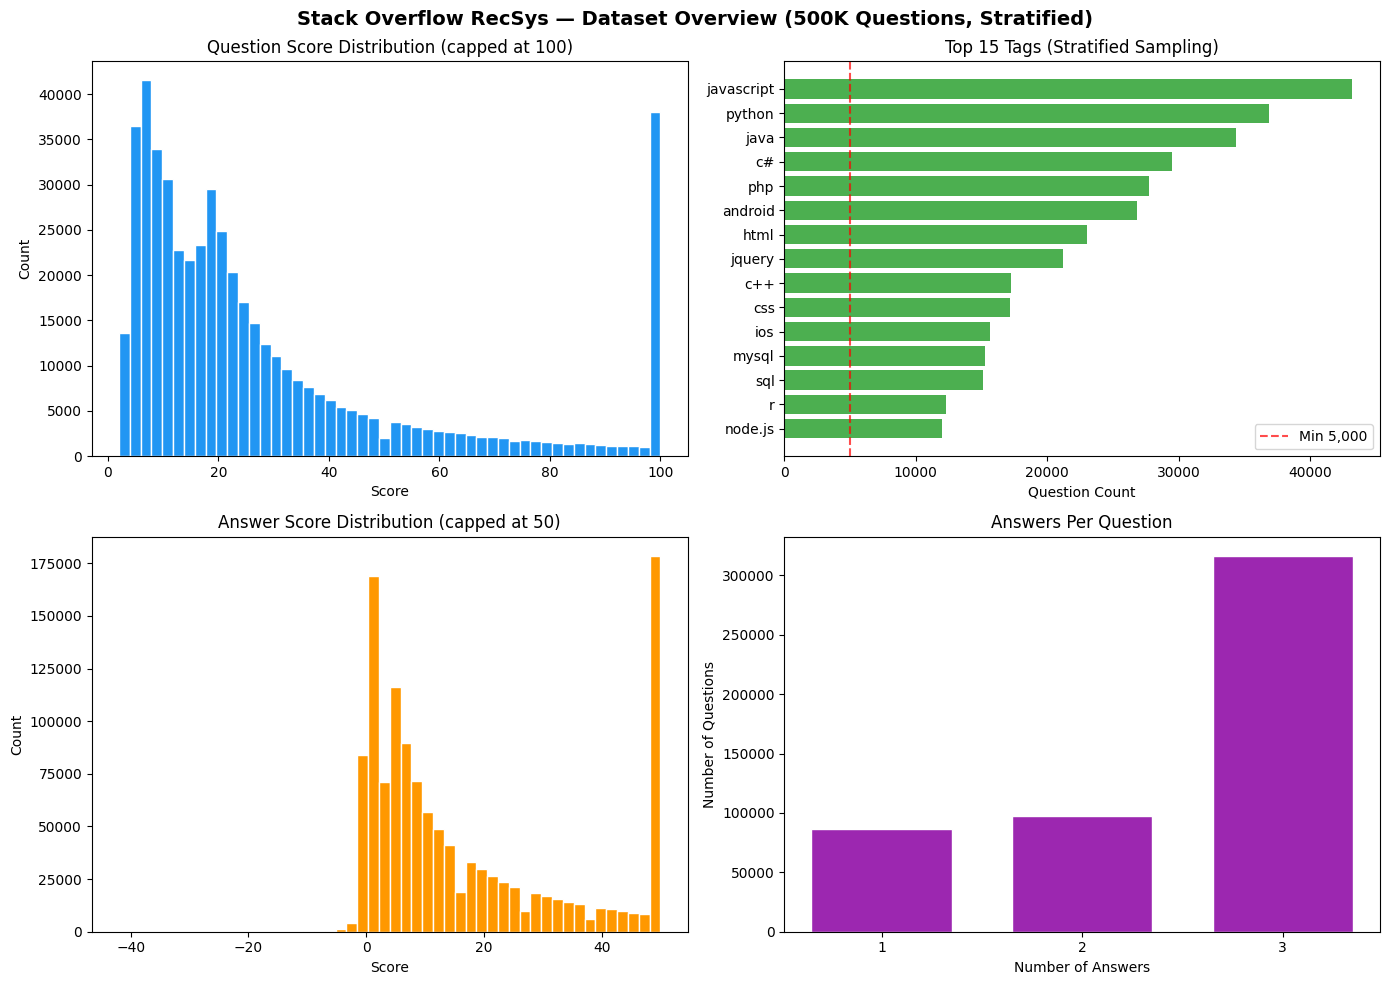

✅ Visualization saved


In [18]:
# Visualization
import matplotlib.pyplot as plt
from collections import Counter

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Stack Overflow RecSys — Dataset Overview (500K Questions, Stratified)',
             fontsize=14, fontweight='bold')

# 1. Question score distribution
axes[0, 0].hist(questions_df['score'].clip(upper=100), bins=50,
                color='#2196F3', edgecolor='white')
axes[0, 0].set_title('Question Score Distribution (capped at 100)')
axes[0, 0].set_xlabel('Score')
axes[0, 0].set_ylabel('Count')

# 2. Stratified tag distribution
tag_dist = questions_df['primary_tag'].value_counts()
top15 = tag_dist.head(15)
colors = ['#4CAF50' if v >= MIN_PER_TAG else '#F44336' for v in top15.values[::-1]]
axes[0, 1].barh(top15.index[::-1], top15.values[::-1], color=colors)
axes[0, 1].axvline(x=MIN_PER_TAG, color='red', linestyle='--', alpha=0.7, label=f'Min {MIN_PER_TAG:,}')
axes[0, 1].set_title('Top 15 Tags (Stratified Sampling)')
axes[0, 1].set_xlabel('Question Count')
axes[0, 1].legend()

# 3. Answer score distribution
axes[1, 0].hist(answers_df['score'].clip(upper=50), bins=50,
                color='#FF9800', edgecolor='white')
axes[1, 0].set_title('Answer Score Distribution (capped at 50)')
axes[1, 0].set_xlabel('Score')
axes[1, 0].set_ylabel('Count')

# 4. Answers per question
answers_per_q_all = answers_df.groupby('parent_id').size()
axes[1, 1].hist(answers_per_q_all, bins=[0.5, 1.5, 2.5, 3.5],
                color='#9C27B0', edgecolor='white', rwidth=0.7)
axes[1, 1].set_title('Answers Per Question')
axes[1, 1].set_xlabel('Number of Answers')
axes[1, 1].set_ylabel('Number of Questions')
axes[1, 1].set_xticks([1, 2, 3])

plt.tight_layout()
plt.savefig('dataset_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Visualization saved')